## 0. Set TF to CPU (prevents VRAM conflict with YOLOv8)

In [1]:
# ⚠️ Must run FIRST before any other imports
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # TF on CPU, GPU free for YOLOv8
print('✅ TF set to CPU — GPU reserved for YOLOv8')

✅ TF set to CPU — GPU reserved for YOLOv8


## 1. Environment Verification

In [2]:
import sys
import numpy as np
import tensorflow as tf
import torch
import cv2
from ultralytics import YOLO

print('=' * 55)
print('  Environment')
print('=' * 55)
print(f'  Python      : {sys.version.split()[0]}')
print(f'  NumPy       : {np.__version__}')
print(f'  TensorFlow  : {tf.__version__}')
print(f'  PyTorch     : {torch.__version__}')
print(f'  OpenCV      : {cv2.__version__}')
print()
print('  GPU Status')
print(f'  TF  GPU : {tf.config.list_physical_devices("GPU")} (CPU mode)')
print(f'  PT  GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"}')
if torch.cuda.is_available():
    print(f'  VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print('=' * 55)
print('  ✅ Ready!')

  Environment
  Python      : 3.10.19
  NumPy       : 1.26.4
  TensorFlow  : 2.10.1
  PyTorch     : 2.7.1+cu118
  OpenCV      : 4.12.0

  GPU Status
  TF  GPU : [] (CPU mode)
  PT  GPU : No GPU
  ✅ Ready!


## 2. Configuration

In [3]:
import glob

# ── Paths ──────────────────────────────────────────────────────────────────
FINETUNE_ROOT   = r'D:\Fine Tuning'
CLASSIFIER_PATH = r'D:\Leaf dataset 2\outputs\CustomCNN\CustomCNN_best.keras'
FINETUNE_OUTPUT = os.path.join(FINETUNE_ROOT, 'outputs')

# ── Auto-find fine-tuned YOLOv8 weights ───────────────────────────────────
candidates = glob.glob(os.path.join(FINETUNE_OUTPUT, '**', 'best.pt'), recursive=True)
if candidates:
    FT_WEIGHTS = sorted(candidates)[-1]
    print(f'✅ Found YOLOv8 weights: {FT_WEIGHTS}')
else:
    raise FileNotFoundError(f'No trained weights found in {FINETUNE_OUTPUT}')

# ── PlantDoc Classes (Stage 1 — 29 classes) ───────────────────────────────
PLANTDOC_CLASSES = {
    0 :'Cherry leaf',              1 :'Peach leaf',
    2 :'Corn leaf blight',         3 :'Apple rust leaf',
    4 :'Potato leaf late blight',  5 :'Strawberry leaf',
    6 :'Corn rust leaf',           7 :'Tomato leaf late blight',
    8 :'Tomato mold leaf',         9 :'Potato leaf early blight',
    10:'Apple leaf',               11:'Tomato leaf yellow virus',
    12:'Blueberry leaf',           13:'Tomato leaf mosaic virus',
    14:'Raspberry leaf',           15:'Tomato leaf bacterial spot',
    16:'Squash Powdery mildew leaf', 17:'grape leaf',
    18:'Corn Gray leaf spot',      19:'Tomato Early blight leaf',
    20:'Apple Scab Leaf',          21:'Tomato Septoria leaf spot',
    22:'Tomato leaf',              23:'Soyabean leaf',
    24:'Bell_pepper leaf spot',    25:'Bell_pepper leaf',
    26:'grape leaf black rot',     27:'Potato leaf',
    28:'Tomato two spotted spider mites leaf',
}

# ── Classifier Classes (Stage 2 — 38 classes) ─────────────────────────────
CLASSIFIER_CLASSES = [
    'Apple___Apple_scab',            'Apple___Black_rot',
    'Apple___Cedar_apple_rust',      'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',             'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',        'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight',         'Potato___Late_blight',
    'Potato___healthy',              'Raspberry___healthy',
    'Soybean___healthy',             'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',      'Strawberry___healthy',
    'Tomato___Bacterial_spot',       'Tomato___Early_blight',
    'Tomato___Late_blight',          'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',  'Tomato___healthy'
]

# ── Species Filter Map ────────────────────────────────────────────────────
# Maps PlantDoc coarse label → expected species keyword in CLASSIFIER_CLASSES
SPECIES_FILTER = {
    'Apple Scab Leaf'             : 'Apple',
    'Apple leaf'                  : 'Apple',
    'Apple rust leaf'             : 'Apple',
    'Tomato leaf'                 : 'Tomato',
    'Tomato leaf late blight'     : 'Tomato',
    'Tomato leaf bacterial spot'  : 'Tomato',
    'Tomato Early blight leaf'    : 'Tomato',
    'Tomato Septoria leaf spot'   : 'Tomato',
    'Tomato mold leaf'            : 'Tomato',
    'Tomato leaf yellow virus'    : 'Tomato',
    'Tomato leaf mosaic virus'    : 'Tomato',
    'Tomato two spotted spider mites leaf': 'Tomato',
    'Potato leaf'                 : 'Potato',
    'Potato leaf early blight'    : 'Potato',
    'Potato leaf late blight'     : 'Potato',
    'Corn leaf blight'            : 'Corn_(maize)',
    'Corn rust leaf'              : 'Corn_(maize)',
    'Corn Gray leaf spot'         : 'Corn_(maize)',
    'grape leaf'                  : 'Grape',
    'grape leaf black rot'        : 'Grape',
    'Peach leaf'                  : 'Peach',
    'Cherry leaf'                 : 'Cherry_(including_sour)',
    'Strawberry leaf'             : 'Strawberry',
    'Blueberry leaf'              : 'Blueberry',
    'Raspberry leaf'              : 'Raspberry',
    'Soyabean leaf'               : 'Soybean',
    'Squash Powdery mildew leaf'  : 'Squash',
    'Bell_pepper leaf'            : 'Pepper,_bell',
    'Bell_pepper leaf spot'       : 'Pepper,_bell',
}

# ── Box colors per detection region ───────────────────────────────────────
BOX_COLORS = [
    (52,  152, 219),  # blue
    (46,  204, 113),  # green
    (231, 76,  60),   # red
    (155, 89,  182),  # purple
    (241, 196, 15),   # yellow
    (230, 126, 34),   # orange
    (26,  188, 156),  # teal
    (52,  73,  94),   # dark blue
]

print('✅ Configuration loaded')
print(f'   YOLOv8 weights : {FT_WEIGHTS}')
print(f'   Classifier     : {CLASSIFIER_PATH}')
print(f'   Species filter : {len(SPECIES_FILTER)} mappings')

✅ Found YOLOv8 weights: D:\Fine Tuning\outputs\yolov8m_plantdoc2\weights\best.pt
✅ Configuration loaded
   YOLOv8 weights : D:\Fine Tuning\outputs\yolov8m_plantdoc2\weights\best.pt
   Classifier     : D:\Leaf dataset 2\outputs\CustomCNN\CustomCNN_best.keras
   Species filter : 29 mappings


## 3. Load Both Models

In [4]:
import tensorflow as tf
import numpy as np
import cv2

# ── Stage 1: PlantDoc YOLOv8 detector (GPU) ───────────────────────────────
print('Loading Stage 1 — PlantDoc YOLOv8 detector (GPU)...')
detector = YOLO(FT_WEIGHTS)
print(f'  ✅ Loaded: {FT_WEIGHTS}')

# ── Stage 2: TF CustomCNN classifier (CPU) ────────────────────────────────
print('\nLoading Stage 2 — TF CustomCNN classifier (CPU)...')
classifier = tf.keras.models.load_model(CLASSIFIER_PATH)
_ = classifier.predict(np.zeros((1, 224, 224, 3), 'float32'), verbose=0)
print(f'  ✅ Loaded: {CLASSIFIER_PATH}')

print('\n' + '='*55)
print('  ✅ Both models ready!')
print('='*55)
print(f'  Stage 1 : YOLOv8m PlantDoc — 29 classes  — GPU')
print(f'  Stage 2 : CustomCNN (TF)   — 38 classes  — CPU')
print(f'  Filter  : Species-constrained classification')
print('='*55)

Loading Stage 1 — PlantDoc YOLOv8 detector (GPU)...
  ✅ Loaded: D:\Fine Tuning\outputs\yolov8m_plantdoc2\weights\best.pt

Loading Stage 2 — TF CustomCNN classifier (CPU)...
  ✅ Loaded: D:\Leaf dataset 2\outputs\CustomCNN\CustomCNN_best.keras

  ✅ Both models ready!
  Stage 1 : YOLOv8m PlantDoc — 29 classes  — GPU
  Stage 2 : CustomCNN (TF)   — 38 classes  — CPU
  Filter  : Species-constrained classification


## 4. 2-Stage Pipeline with Species Filter

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

def classify_with_filter(crop_bgr, coarse_label, preds=None):
    """
    Classify a crop using CustomCNN, constrained by the coarse species label.
    If the top prediction is wrong species, find best match within correct species.
    """
    if preds is None:
        inp   = np.expand_dims(
                    cv2.resize(
                        cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB),
                        (224, 224)
                    ).astype('float32') / 255.0, axis=0)
        preds = classifier.predict(inp, verbose=0)

    top_idx  = np.argmax(preds[0])
    top_name = CLASSIFIER_CLASSES[top_idx]
    top_conf = float(preds[0][top_idx])

    # ── Apply species filter ──────────────────────────────────────────────
    expected_species = SPECIES_FILTER.get(coarse_label, None)

    if expected_species and expected_species.lower() not in top_name.lower():
        # Top prediction is wrong species — find best within correct species
        species_matches = [
            (j, float(preds[0][j]))
            for j, c in enumerate(CLASSIFIER_CLASSES)
            if expected_species.lower() in c.lower()
        ]
        if species_matches:
            best_idx  = max(species_matches, key=lambda x: x[1])
            cls_name  = CLASSIFIER_CLASSES[best_idx[0]].replace('___', ' — ')
            cls_conf  = best_idx[1]
            filtered  = True
        else:
            # No match found — fall back to top prediction
            cls_name = top_name.replace('___', ' — ')
            cls_conf = top_conf
            filtered = False
    else:
        cls_name = top_name.replace('___', ' — ')
        cls_conf = top_conf
        filtered = False

    return cls_name, cls_conf, filtered


def predict(image_path, conf_threshold=0.40, show=True, save_path=None):
    """
    2-Stage Pipeline with Species Filter:
      Stage 1: YOLOv8m (PlantDoc) → locate leaves + coarse species label
      Stage 2: CustomCNN (TF)     → disease classification constrained by species
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f'Image not found: {image_path}')

    # ── Stage 1 — detect leaves ───────────────────────────────────────────
    results    = detector(image_path, conf=conf_threshold, verbose=False)[0]
    detections = []

    if results.boxes is None or len(results.boxes) == 0:
        print(f'⚠️  No leaves detected at conf={conf_threshold:.0%}')
        print('   Try lowering conf_threshold (e.g. 0.25)')
        return detections

    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    for i, box in enumerate(results.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf        = float(box.conf[0])
        coarse_label    = PLANTDOC_CLASSES[int(box.cls[0])]

        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # ── Stage 2 — classify with species filter ────────────────────────
        inp = np.expand_dims(
                  cv2.resize(
                      cv2.cvtColor(crop, cv2.COLOR_BGR2RGB),
                      (224, 224)
                  ).astype('float32') / 255.0, axis=0)
        preds = classifier.predict(inp, verbose=0)

        cls_name, cls_conf, was_filtered = classify_with_filter(
            crop, coarse_label, preds
        )

        detections.append({
            'region'      : i + 1,
            'coarse'      : coarse_label,
            'disease'     : cls_name,
            'det_conf'    : det_conf,
            'cls_conf'    : cls_conf,
            'filtered'    : was_filtered,
            'bbox'        : (x1, y1, x2, y2),
        })

        # ── Draw bounding box ─────────────────────────────────────────────
        color = tuple(c / 255 for c in BOX_COLORS[i % len(BOX_COLORS)])
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2.5, edgecolor=color, facecolor=(*color, 0.08)
        ))
        filter_tag = ' 🔧' if was_filtered else ''
        ax.text(
            x1, max(y1 - 5, 10),
            f'#{i+1} {cls_name.split(" — ")[-1]}{filter_tag}\n'
            f'det:{det_conf:.0%}  cls:{cls_conf:.0%}',
            color='white', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.88)
        )

    # ── Print summary ─────────────────────────────────────────────────────
    print(f'\n{"─"*65}')
    print(f'  📍 {os.path.basename(image_path)}')
    print(f'  🔍 {len(detections)} leaf region(s) detected')
    print(f'{"─"*65}')
    for det in detections:
        filter_note = ' (species filter applied 🔧)' if det['filtered'] else ''
        print(f"  Region {det['region']:>2}: {det['disease']}{filter_note}")
        print(f"           Coarse  : {det['coarse']}")
        print(f"           Det: {det['det_conf']:.2%}  |  Cls: {det['cls_conf']:.2%}")
        print()

    # ── Show / save ───────────────────────────────────────────────────────
    ax.axis('off')
    ax.set_title(
        f'Plant Disease Detection — {os.path.basename(image_path)}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved → {save_path}')
    if show:
        plt.show()
    plt.close()

    return detections

print('✅ Pipeline with species filter ready!')
print('   🔧 = species filter was applied to fix cross-species misclassification')

✅ Pipeline with species filter ready!
   🔧 = species filter was applied to fix cross-species misclassification


## 5. Test on a Single Image


─────────────────────────────────────────────────────────────────
  📍 WhatsApp Image 2026-03-02 at 1.22.46 AM.jpeg
  🔍 8 leaf region(s) detected
─────────────────────────────────────────────────────────────────
  Region  1: Tomato — Tomato_mosaic_virus (species filter applied 🔧)
           Coarse  : Tomato leaf
           Det: 85.67%  |  Cls: 13.20%

  Region  2: Tomato — Tomato_mosaic_virus (species filter applied 🔧)
           Coarse  : Tomato leaf
           Det: 83.47%  |  Cls: 0.02%

  Region  3: Tomato — Tomato_mosaic_virus (species filter applied 🔧)
           Coarse  : Tomato leaf
           Det: 83.44%  |  Cls: 0.83%

  Region  4: Tomato — Tomato_mosaic_virus (species filter applied 🔧)
           Coarse  : Tomato leaf
           Det: 80.55%  |  Cls: 18.24%

  Region  5: Tomato — Bacterial_spot (species filter applied 🔧)
           Coarse  : Tomato leaf
           Det: 67.21%  |  Cls: 0.01%

  Region  6: Tomato — Tomato_Yellow_Leaf_Curl_Virus (species filter applied 🔧)
       

C:\Users\LOQ\AppData\Local\Temp\ipykernel_24772\3184151587.py:138: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


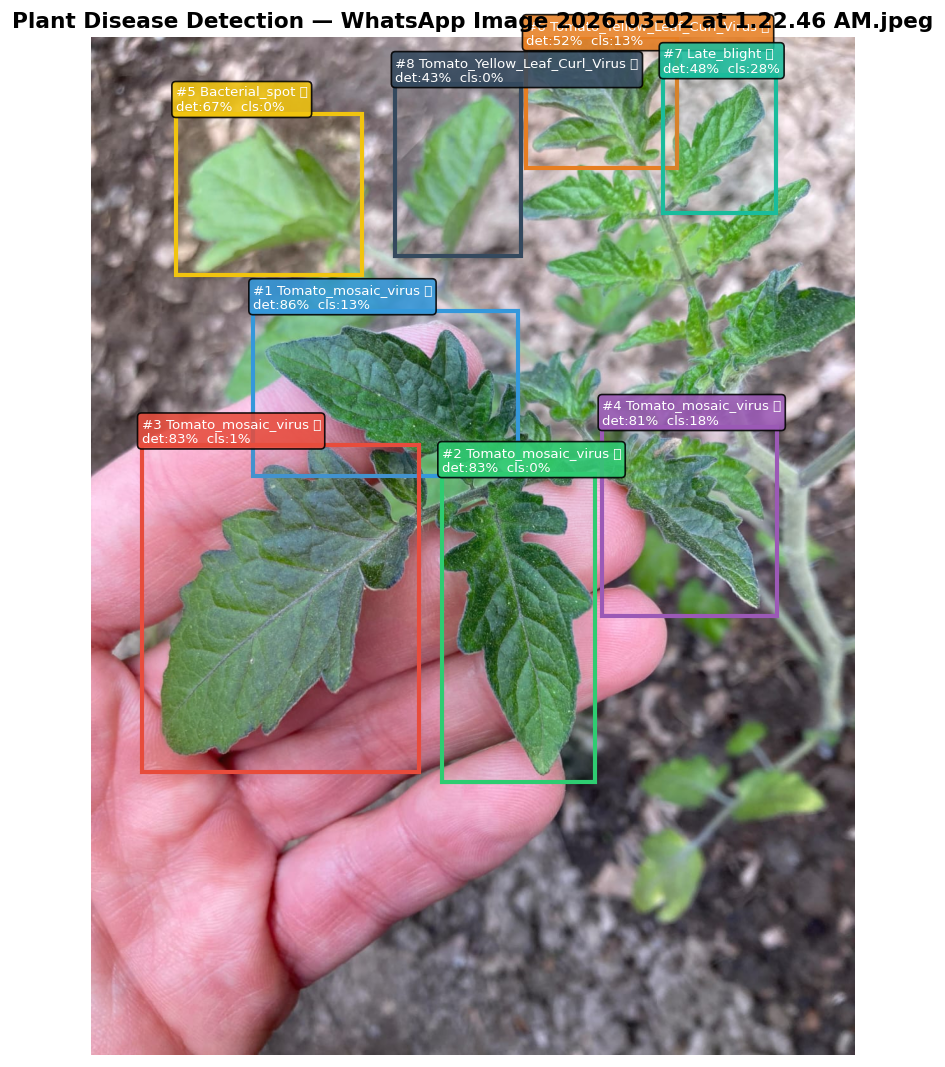

In [9]:
# ── Change this to your image path ───────────────────────────────────────
IMAGE_PATH = r"C:\Users\LOQ\Downloads\WhatsApp Image 2026-03-02 at 1.22.46 AM.jpeg"

if os.path.exists(IMAGE_PATH):
    results = predict(
        IMAGE_PATH,
        conf_threshold = 0.40,
        show           = True,
    )
else:
    print(f'⚠️  File not found: {IMAGE_PATH}')
    print('    Update IMAGE_PATH and re-run.')

## 6. Test on Multiple Validation Images

In [ ]:
import random

val_images = []
for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.png', '*.PNG']:
    val_images += glob.glob(os.path.join(FINETUNE_ROOT, 'images', 'val', ext))
val_images = list(set(val_images))

sample = random.sample(val_images, min(5, len(val_images)))
print(f'Testing on {len(sample)} validation images...\n')

for img_path in sample:
    predict(img_path, conf_threshold=0.40, show=True)

## 7. Batch Inference → CSV Export

In [ ]:
import pandas as pd
from tqdm import tqdm
from datetime import datetime

def batch_predict(image_dir, conf_threshold=0.40, output_csv=None):
    paths = []
    for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.png', '*.PNG']:
        paths += glob.glob(os.path.join(image_dir, ext))
    paths = list(set(paths))
    print(f'Found {len(paths)} images in {image_dir}')

    rows = []
    for img_path in tqdm(paths, desc='Batch inference'):
        try:
            dets = predict(
                img_path,
                conf_threshold = conf_threshold,
                show           = False,
                save_path      = None,
            )
            if dets:
                for det in dets:
                    rows.append({
                        'image'          : os.path.basename(img_path),
                        'region'         : det['region'],
                        'coarse_label'   : det['coarse'],
                        'disease'        : det['disease'],
                        'det_confidence' : round(det['det_conf'], 4),
                        'cls_confidence' : round(det['cls_conf'], 4),
                        'species_filtered': det['filtered'],
                    })
            else:
                rows.append({
                    'image'          : os.path.basename(img_path),
                    'region'         : 0,
                    'coarse_label'   : 'No detection',
                    'disease'        : '—',
                    'det_confidence' : 0,
                    'cls_confidence' : 0,
                    'species_filtered': False,
                })
        except Exception as e:
            print(f'  ⚠️  {os.path.basename(img_path)}: {e}')

    df = pd.DataFrame(rows)

    if output_csv is None:
        ts         = datetime.now().strftime('%Y%m%d_%H%M%S')
        output_csv = os.path.join(FINETUNE_OUTPUT, f'predictions_{ts}.csv')

    df.to_csv(output_csv, index=False)

    filtered_count = df['species_filtered'].sum()
    print(f'\n✅ {len(df)} rows saved → {output_csv}')
    print(f'   Species filter applied: {filtered_count} times ({filtered_count/len(df)*100:.1f}%)')
    print('\n📊 Top diseases detected:')
    print(df['disease'].value_counts().head(10).to_string())
    return df


# Run on validation set
df_results = batch_predict(
    image_dir      = os.path.join(FINETUNE_ROOT, 'images', 'val'),
    conf_threshold = 0.40,
)

## 8. Summary

In [ ]:
print('=' * 62)
print('  🌿 Plant Disease Detection — 2-Stage + Species Filter')
print('=' * 62)
print()
print('  Environment')
print('    tf_env: TF 2.10.1 (CPU) | PyTorch 2.7.1+cu118 (GPU)')
print('    GPU   : RTX 4060 Laptop (8GB VRAM)')
print()
print('  Stage 1 — YOLOv8m Field Detector (PlantDoc)  [GPU]')
print(f'    Classes : 29 disease/leaf classes')
print(f'    mAP50   : 69.57%')
print(f'    Weights : {FT_WEIGHTS}')
print()
print('  Stage 2 — CustomCNN Classifier (TF)          [CPU]')
print(f'    Classes : 38 disease classes')
print(f'    Val acc : 99.28%')
print(f'    Weights : {CLASSIFIER_PATH}')
print()
print('  Species Filter')
print('    Constrains Stage 2 output to correct plant species')
print('    using Stage 1 coarse label — prevents cross-species')
print('    misclassification (e.g. Apple leaf → Corn disease)')
print('    🔧 tag shown when filter was applied')
print()
print('  Example Output')
print('    Region 1: Apple — Apple_scab')
print('              Coarse: Apple Scab Leaf')
print('              Det: 97% | Cls: 100%')
print('    Region 2: Apple — Apple_scab 🔧')
print('              Coarse: Apple leaf')
print('              Det: 88% | Cls: 61%  ← filtered from Corn')
print('=' * 62)